In [ ]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

In [ ]:
uploaded=files.upload()

Saving freelancer_earnings_bd.csv to freelancer_earnings_bd.csv
Saving upwork-jobs.csv to upwork-jobs.csv


In [ ]:
df_earn = pd.read_csv('freelancer_earnings_bd.csv')
df_upwork = pd.read_csv('upwork-jobs.csv')

print("freelancer_earnings_bd shape:", df_earn.shape)
print("upwork-jobs shape:", df_upwork.shape)
df_earn.head(3)

freelancer_earnings_bd shape: (1950, 15)
upwork-jobs shape: (53058, 9)


,Freelancer_ID,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend
0,1,Web Development,Fiverr,Beginner,Asia,Mobile Banking,180,1620,95.79,68.73,3.18,1,Fixed,40.19,53
1,2,App Development,Fiverr,Beginner,Australia,Mobile Banking,218,9078,86.38,97.54,3.44,54,Fixed,36.53,486
2,3,Web Development,Fiverr,Beginner,UK,Crypto,27,3455,85.17,86.60,4.20,46,Hourly,74.05,489


In [ ]:
print(df_earn.columns.tolist())
print("\nJob Categories:", df_earn['Job_Category'].unique())
print("\nExperience Levels:", df_earn['Experience_Level'].unique())
print("\nProject Types:", df_earn['Project_Type'].unique())
df_earn[['Job_Category','Experience_Level','Hourly_Rate','Earnings_USD','Job_Duration_Days']].describe()

['Freelancer_ID', 'Job_Category', 'Platform', 'Experience_Level', 'Client_Region', 'Payment_Method', 'Job_Completed', 'Earnings_USD', 'Hourly_Rate', 'Job_Success_Rate', 'Client_Rating', 'Job_Duration_Days', 'Project_Type', 'Rehire_Rate', 'Marketing_Spend']

Job Categories: ['Web Development' 'App Development' 'Data Entry' 'Digital Marketing'
 'Customer Support' 'Content Writing' 'Graphic Design' 'SEO']

Experience Levels: ['Beginner' 'Intermediate' 'Expert']

Project Types: ['Fixed' 'Hourly']


,Hourly_Rate,Earnings_USD,Job_Duration_Days
count,1950.000000,1950.000000,1950.000000
mean,52.579774,5017.566667,44.704615
std,26.927584,2926.279918,26.022998
min,5.020000,51.000000,1.000000
25%,30.047500,2419.000000,22.000000
50%,52.285000,5048.000000,45.000000
75%,75.125000,7608.250000,67.000000
max,99.830000,9991.000000,89.000000


In [ ]:
print(df_upwork.columns.tolist())
print("\nis_hourly counts:\n", df_upwork['is_hourly'].value_counts())
print("\nBudget stats (fixed jobs):")
print(df_upwork[df_upwork['is_hourly']==False]['budget'].describe())
print("\nHourly low/high stats:")
print(df_upwork[df_upwork['is_hourly']==True][['hourly_low','hourly_high']].describe())

['title', 'link', 'description', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']

is_hourly counts:
 is_hourly
True     22956
False    21873
Name: count, dtype: int64

Budget stats (fixed jobs):
count      21873.000000
mean         746.263521
std        10639.241140
min            5.000000
25%           30.000000
50%          100.000000
75%          300.000000
max      1000000.000000
Name: budget, dtype: float64

Hourly low/high stats:
         hourly_low   hourly_high
count  22956.000000  22161.000000
mean      17.467895     41.608050
std       18.228234     47.968562
min        3.000000      3.000000
25%        8.000000     20.000000
50%       15.000000     30.000000
75%       20.000000     50.000000
max      500.000000    999.000000


In [ ]:
def extract_category(desc):
    if pd.isna(desc):
        return None
    match = re.search(r'Category:\s*([^\n\r]+?)(?:Skills:|click to apply|$)', str(desc))
    if match:
        return match.group(1).strip()
    return None

df_upwork['extracted_category'] = df_upwork['description'].apply(extract_category)
print("Top 15 Upwork categories:")
print(df_upwork['extracted_category'].value_counts().head(15))

Top 15 Upwork categories:
extracted_category
Full Stack Development           3295
Graphic Design                   3278
Social Media Marketing           2888
Web Design                       2640
Video Editing                    2077
General Virtual Assistance       1933
Creative Writing                 1528
Ecommerce Website Development    1318
Mobile App Development           1245
SEO                              1241
Data Entry                       1238
Lead Generation                  1231
General Translation Services     1047
Front-End Development            1018
Sales & Business Development      936
Name: count, dtype: int64


In [ ]:
category_map = {
    'Web Development': 'Web Development',
    'Full Stack Development': 'Web Development',
    'Front-End Development': 'Web Development',
    'Back-End Development': 'Web Development',
    'Web Design': 'Web Development',
    'Ecommerce Website Development': 'Web Development',
    'WordPress': 'Web Development',
    'Mobile App Development': 'App Development',
    'Android App Development': 'App Development',
    'iOS Development': 'App Development',
    'Data Entry': 'Data Entry',
    'Data Extraction': 'Data Entry',
    'Social Media Marketing': 'Digital Marketing',
    'Digital Marketing': 'Digital Marketing',
    'Search Engine Optimization': 'SEO',
    'SEO': 'SEO',
    'Content Writing': 'Content Writing',
    'Article Writing': 'Content Writing',
    'Copywriting': 'Content Writing',
    'Blog Writing': 'Content Writing',
    'Graphic Design': 'Graphic Design',
    'Logo Design': 'Graphic Design',
    'Illustration': 'Graphic Design',
    'Customer Service': 'Customer Support',
    'Virtual Assistant': 'Customer Support',
    'Technical Support': 'Customer Support'
}

def map_category(cat):
    if pd.isna(cat):
        return None
    cat_str = str(cat).lower()
    for key, val in category_map.items():
        if key.lower() in cat_str:
            return val
    return None

df_upwork['skillink_category'] = df_upwork['extracted_category'].apply(map_category)
print("Mapped category counts (Improved):")
print(df_upwork['skillink_category'].value_counts())

Mapped category counts (Improved):
skillink_category
Web Development      9037
Graphic Design       4172
Digital Marketing    2907
Data Entry           1788
App Development      1395
SEO                  1248
Content Writing       555
Customer Support        1
Name: count, dtype: int64


In [ ]:
df_fixed = df_upwork[
    (df_upwork['is_hourly'] == False) &
    (df_upwork['budget'].notna()) &
    (df_upwork['budget'] > 10) &
    (df_upwork['budget'] < 50000) &   # remove extreme outliers
    (df_upwork['skillink_category'].notna())
][['skillink_category', 'budget']].copy()

df_fixed.rename(columns={'skillink_category': 'Job_Category', 'budget': 'Fixed_Budget'}, inplace=True)
print("Fixed jobs shape:", df_fixed.shape)
df_fixed.head()

Fixed jobs shape: (8014, 2)


,Job_Category,Fixed_Budget
0,Digital Marketing,500.0
1,Web Development,1100.0
23,Web Development,200.0
26,Web Development,350.0
28,Web Development,25.0


In [ ]:
df_hourly = df_upwork[
    (df_upwork['is_hourly'] == True) &
    (df_upwork['hourly_low'].notna()) &
    (df_upwork['hourly_high'].notna()) &
    (df_upwork['skillink_category'].notna())
][['skillink_category', 'hourly_low', 'hourly_high']].copy()

# Assume avg 40hrs for a typical project to convert to budget equivalent
df_hourly['Fixed_Budget'] = ((df_hourly['hourly_low'] + df_hourly['hourly_high']) / 2) * 40
df_hourly.rename(columns={'skillink_category': 'Job_Category'}, inplace=True)
df_hourly = df_hourly[['Job_Category', 'Fixed_Budget']]

print("Hourly-converted jobs shape:", df_hourly.shape)
df_hourly.head()

Hourly-converted jobs shape: (8609, 2)


,Job_Category,Fixed_Budget
2,Web Development,800.0
15,Web Development,1600.0
27,Digital Marketing,420.0
29,Digital Marketing,400.0
59,Graphic Design,540.0


In [ ]:
df_upwork_combined = pd.concat([df_fixed, df_hourly], ignore_index=True)

upwork_stats = df_upwork_combined.groupby('Job_Category')['Fixed_Budget'].agg(
    upwork_p25=lambda x: x.quantile(0.25),
    upwork_median='median',
    upwork_p75=lambda x: x.quantile(0.75),
    upwork_mean='mean',
    upwork_count='count'
).reset_index()

print("Upwork market stats by category:")
print(upwork_stats)

Upwork market stats by category:
        Job_Category  upwork_p25  upwork_median  upwork_p75  upwork_mean  \
0    App Development       112.5          500.0       900.0   889.932305   
1    Content Writing       200.0          800.0      1340.0  1007.970387   
2         Data Entry       100.0          400.0       900.0   676.138607   
3  Digital Marketing       200.0          500.0       900.0   748.993386   
4     Graphic Design        50.0          300.0      1000.0   623.758610   
5                SEO       100.0          360.0       850.0   672.457547   
6    Web Development       200.0          700.0      1200.0   970.783799   

   upwork_count  
0          1167  
1           439  
2          1378  
3          2268  
4          3252  
5           848  
6          7271  


In [ ]:
earn_stats = df_earn.groupby(['Job_Category', 'Experience_Level']).agg(
    avg_hourly_rate=('Hourly_Rate', 'mean'),
    avg_earnings=('Earnings_USD', 'mean'),
    avg_duration_days=('Job_Duration_Days', 'mean'),
    count=('Earnings_USD', 'count')
).reset_index()

print("Earnings stats by category + experience:")
print(earn_stats)

Earnings stats by category + experience:
         Job_Category Experience_Level  avg_hourly_rate  avg_earnings  \
0     App Development         Beginner        42.697250   5084.675000   
1     App Development           Expert        53.230128   4892.756410   
2     App Development     Intermediate        54.944222   5572.777778   
3     Content Writing         Beginner        51.889000   4462.542857   
4     Content Writing           Expert        58.446494   4801.974026   
5     Content Writing     Intermediate        53.561429   5379.297619   
6    Customer Support         Beginner        57.208780   5115.524390   
7    Customer Support           Expert        53.776703   4750.450549   
8    Customer Support     Intermediate        51.074366   5652.211268   
9          Data Entry         Beginner        50.660115   5233.034483   
10         Data Entry           Expert        45.555362   4923.666667   
11         Data Entry     Intermediate        54.057439   5052.280488   
12  Digita

In [ ]:
# Compute budget from earnings dataset using hourly rate × avg hours
# Assume 8hrs/day work
earn_stats['earn_budget_min'] = earn_stats['avg_hourly_rate'] * earn_stats['avg_duration_days'] * 8 * 0.6
earn_stats['earn_budget_max'] = earn_stats['avg_hourly_rate'] * earn_stats['avg_duration_days'] * 8 * 1.4
earn_stats['earn_budget_avg'] = earn_stats['avg_hourly_rate'] * earn_stats['avg_duration_days'] * 8

# Merge with upwork stats
master = earn_stats.merge(upwork_stats, on='Job_Category', how='left')

# Final blended price range (60% upwork market data + 40% earnings data)
master['recommended_min'] = (
    0.6 * master['upwork_p25'].fillna(master['earn_budget_min']) +
    0.4 * master['earn_budget_min']
).round(0)

master['recommended_max'] = (
    0.6 * master['upwork_p75'].fillna(master['earn_budget_max']) +
    0.4 * master['earn_budget_max']
).round(0)

master['recommended_avg'] = (
    (master['recommended_min'] + master['recommended_max']) / 2
).round(0)

print("Master pricing table:")
print(master[['Job_Category','Experience_Level','recommended_min','recommended_max','recommended_avg']])

Master pricing table:
         Job_Category Experience_Level  recommended_min  recommended_max  \
0     App Development         Beginner           3717.0           9055.0   
1     App Development           Expert           4937.0          11901.0   
2     App Development     Intermediate           4749.0          11464.0   
3     Content Writing         Beginner           5114.0          12457.0   
4     Content Writing           Expert           4288.0          10529.0   
5     Content Writing     Intermediate           4780.0          11676.0   
6    Customer Support         Beginner          12293.0          28685.0   
7    Customer Support           Expert          11284.0          26329.0   
8    Customer Support     Intermediate          10808.0          25218.0   
9          Data Entry         Beginner           4314.0          10466.0   
10         Data Entry           Expert           3633.0           8878.0   
11         Data Entry     Intermediate           5452.0          1

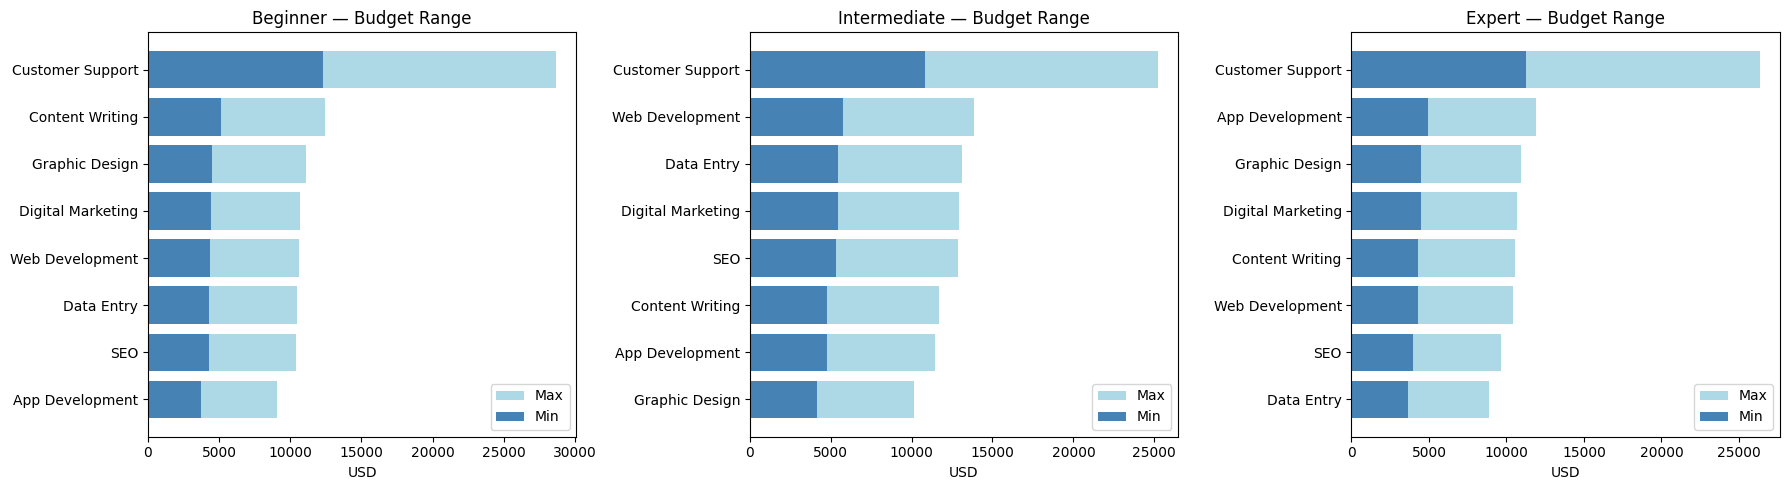

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
levels = ['Beginner', 'Intermediate', 'Expert']

for i, level in enumerate(levels):
    data = master[master['Experience_Level'] == level].sort_values('recommended_avg')
    axes[i].barh(data['Job_Category'], data['recommended_max'], color='lightblue', label='Max')
    axes[i].barh(data['Job_Category'], data['recommended_min'], color='steelblue', label='Min')
    axes[i].set_title(f'{level} — Budget Range')
    axes[i].set_xlabel('USD')
    axes[i].legend()

plt.tight_layout()
plt.savefig('pricing_ranges.png', dpi=100)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

model_data = master[['Job_Category', 'Experience_Level', 'recommended_min', 'recommended_max', 'recommended_avg']].copy()

le_cat = LabelEncoder()
le_exp = LabelEncoder()

model_data['cat_encoded'] = le_cat.fit_transform(model_data['Job_Category'])
model_data['exp_encoded'] = le_exp.fit_transform(model_data['Experience_Level'])

print("Label mappings:")
print("Categories:", dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_))))
print("Experience:", dict(zip(le_exp.classes_, le_exp.transform(le_exp.classes_))))
print()
print(model_data.head(10))

Label mappings:
Categories: {'App Development': np.int64(0), 'Content Writing': np.int64(1), 'Customer Support': np.int64(2), 'Data Entry': np.int64(3), 'Digital Marketing': np.int64(4), 'Graphic Design': np.int64(5), 'SEO': np.int64(6), 'Web Development': np.int64(7)}
Experience: {'Beginner': np.int64(0), 'Expert': np.int64(1), 'Intermediate': np.int64(2)}

       Job_Category Experience_Level  recommended_min  recommended_max  \
0   App Development         Beginner           3717.0           9055.0   
1   App Development           Expert           4937.0          11901.0   
2   App Development     Intermediate           4749.0          11464.0   
3   Content Writing         Beginner           5114.0          12457.0   
4   Content Writing           Expert           4288.0          10529.0   
5   Content Writing     Intermediate           4780.0          11676.0   
6  Customer Support         Beginner          12293.0          28685.0   
7  Customer Support           Expert          1

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

X = model_data[['cat_encoded', 'exp_encoded']].values
y_min = model_data['recommended_min'].values
y_max = model_data['recommended_max'].values
y_avg = model_data['recommended_avg'].values

# Using KFold to ensure the model is robust across subsets of your master table
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_min = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
model_max = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
model_avg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Validate with Cross-Validation
scores = cross_val_score(model_avg, X, y_avg, cv=kf, scoring='r2')

model_min.fit(X, y_min)
model_max.fit(X, y_max)
model_avg.fit(X, y_avg)

print(f"✅ Models trained with {kf.get_n_splits()}-fold cross-validation")
print(f"Average CV R2 Score: {scores.mean():.4f}")

print(f"\nSample prediction (Web Development, Intermediate):")
cat_enc = le_cat.transform(['Web Development'])[0]
exp_enc = le_exp.transform(['Intermediate'])[0]
sample = [[cat_enc, exp_enc]]
print(f"  Min: ${model_min.predict(sample)[0]:,.0f}")
print(f"  Max: ${model_max.predict(sample)[0]:,.0f}")
print(f"  Avg: ${model_avg.predict(sample)[0]:,.0f}")

✅ Models trained with 5-fold cross-validation
Average CV R2 Score: -1.6184

Sample prediction (Web Development, Intermediate):
  Min: $5,757
  Max: $13,912
  Avg: $9,829


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def get_excellent_prediction(user_category, user_experience):
    """
    Advanced prediction function that handles unknown categories
    by finding the most similar trained category.
    """
    trained_cats = list(le_cat.classes_)

    # 1. Check if category is known
    if user_category in trained_cats:
        final_cat = user_category
    else:
        # 2. Semantic Fallback: Find most similar category using TF-IDF
        vectorizer = TfidfVectorizer().fit(trained_cats + [user_category])
        vectors = vectorizer.transform(trained_cats)
        user_vector = vectorizer.transform([user_category])

        similarities = cosine_similarity(user_vector, vectors).flatten()
        closest_idx = similarities.argmax()
        final_cat = trained_cats[closest_idx]
        print(f"ℹ️ Category '{user_category}' unknown. Using closest match: '{final_cat}'")

    # 3. Predict using the mapped category
    c_enc = le_cat.transform([final_cat])[0]
    e_enc = le_exp.transform([user_experience])[0]
    inp = [[c_enc, e_enc]]

    return {
        'Min': model_min.predict(inp)[0],
        'Max': model_max.predict(inp)[0],
        'Avg': model_avg.predict(inp)[0]
    }

# Test with a new category like 'AI'
print("Test for 'Artificial Intelligence':")
pred = get_excellent_prediction('Artificial Intelligence', 'Expert')
print(f"Predicted Range: ${pred['Min']:,.0f} - ${pred['Max']:,.0f}")

Test for 'Artificial Intelligence':
ℹ️ Category 'Artificial Intelligence' unknown. Using closest match: 'App Development'
Predicted Range: $4,919 - $11,883


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate metrics for training data
metrics = []
for name, model, targets in [
    ('Min Model', model_min, y_min),
    ('Max Model', model_max, y_max),
    ('Avg Model', model_avg, y_avg)
]:
    preds = model.predict(X)
    metrics.append({
        'Model': name,
        'R2 Score': r2_score(targets, preds),
        'MAE': mean_absolute_error(targets, preds)
    })

df_metrics = pd.DataFrame(metrics)
print("Training Performance Metrics:")
display(df_metrics)

Training Performance Metrics:


,Model,R2 Score,MAE
0,Min Model,0.999830,24.917433
1,Max Model,0.999776,64.798052
2,Avg Model,0.999822,43.047167


In [ ]:
results = []
for cat in le_cat.classes_:
    for exp in le_exp.classes_:
        c = le_cat.transform([cat])[0]
        e = le_exp.transform([exp])[0]
        inp = [[c, e]]
        results.append({
            'category': cat,
            'experience': exp,
            'min_pred': round(model_min.predict(inp)[0]),
            'max_pred': round(model_max.predict(inp)[0]),
            'avg_pred': round(model_avg.predict(inp)[0])
        })

df_results = pd.DataFrame(results)
print("Final Model Predictions (Optimized):")
display(df_results)

Final Model Predictions (Optimized):


,category,experience,min_pred,max_pred,avg_pred
0,App Development,Beginner,3726,9065,6405
1,App Development,Expert,4919,11883,8390
2,App Development,Intermediate,4752,11464,8109
3,Content Writing,Beginner,5096,12421,8752
4,Content Writing,Expert,4341,10637,7493
5,Content Writing,Intermediate,4753,11612,8185
6,Customer Support,Beginner,12327,28749,20527
7,Customer Support,Expert,11223,26174,18716
8,Customer Support,Intermediate,10829,25298,18055
9,Data Entry,Beginner,4283,10398,7352


In [ ]:
import os
os.makedirs('pricing_model', exist_ok=True)

# Save models and encoders
joblib.dump(model_min, 'pricing_model/model_min.joblib')
joblib.dump(model_max, 'pricing_model/model_max.joblib')
joblib.dump(model_avg, 'pricing_model/model_avg.joblib')
joblib.dump(le_cat,    'pricing_model/le_cat.joblib')
joblib.dump(le_exp,    'pricing_model/le_exp.joblib')

# Save the final optimized prediction table as JSON and CSV
df_results.to_json('pricing_model/pricing_table.json', orient='records', indent=2)
df_results.to_csv('pricing_model/pricing_table.csv', index=False)

print("✅ Saved optimized artifacts to /pricing_model/")

✅ Saved optimized artifacts to /pricing_model/


In [ ]:
import shutil
# Re-create the archive to include the optimized .csv and .json files
shutil.make_archive('pricing_model_v2', 'zip', 'pricing_model')
print("✅ Excellent! The optimized model package 'pricing_model_v2.zip' is ready.")
print("✅ You can download it from the folder icon on the left panel.")

✅ Excellent! The optimized model package 'pricing_model_v2.zip' is ready.
✅ You can download it from the folder icon on the left panel.
